# Michaelis-Menten
***
## Setup the Environment
***

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
!{sys.executable} -m pip install matplotlib
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [3]:
import gillespy3d_pp as gillespy2

In [4]:
gillespy2.__file__

'/Users/anisgolriz/Desktop/GillesPy3D/simulation_lib/gillespy3d_pp/__init__.py'

In [5]:
def create_michaelis_menten(parameter_values=None):
    # Initialize Model
    model = gillespy2.Model(name="Michaelis_Menten")

    # Define Variables (GillesPy2.Species)
    A = gillespy2.Species(name='Substrate', initial_value=301)
    B = gillespy2.Species(name='Enzyme', initial_value=120)
    C = gillespy2.Species(name='Enzyme_Substrate_Complex', 
                          initial_value=0)
    D = gillespy2.Species(name='Product', initial_value=0)
    
    # Add Variables to Model
    model.add_species([A, B, C, D])
    

    # Define Parameters
    rate1 = gillespy2.Parameter(name='rate1', expression=0.0017)
    rate2 = gillespy2.Parameter(name='rate2', expression=0.5)
    rate3 = gillespy2.Parameter(name='rate3', expression=0.1)
    
    # Add Parameters to Model
    model.add_parameter([rate1, rate2, rate3])
    
    # Define Reactions
    r1 = gillespy2.Reaction(
        name="r1", reactants={'Substrate': 1, 'Enzyme': 1}, 
        products={'Enzyme_Substrate_Complex': 1}, rate='rate1'
    )
    r2 = gillespy2.Reaction(
        name="r2", reactants={'Enzyme_Substrate_Complex': 1}, 
        products={'Substrate': 1, 'Enzyme': 1}, rate='rate2'
    )
    r3 = gillespy2.Reaction(
        name="r3", reactants={'Enzyme_Substrate_Complex': 1}, 
        products={'Enzyme': 1, 'Product': 1}, rate='rate3'
    )
    
    # Add Reactions to Model
    model.add_reaction([r1, r2, r3])
    
    # Define Timespan
    tspan = gillespy2.TimeSpan.linspace(t=100, num_points=101)
    
    # Set Model Timespan
    model.timespan(tspan)
    return model

### Instantiate the Model

In [6]:
model = create_michaelis_menten()

In [7]:
dir(gillespy2)

['Model',
 'NumPySSASolver',
 'Parameter',
 'Reaction',
 'Result',
 'Simulation',
 'Species',
 'TimeSpan',
 '__author__',
 '__builtins__',
 '__cached__',
 '__copyright__',
 '__description__',
 '__doc__',
 '__email__',
 '__file__',
 '__license__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__url__',
 '__version__',
 'core',
 'error',
 'log',
 'logging',
 'model',
 'parameter',
 'reaction',
 'result',
 'simulation',
 'solvers',
 'species',
 'sys',
 'timespan',
 'utils',
 'version']

In [8]:
# The GillesPy2 way to run GillesPy3D
result = model.run()
result.plot()

AttributeError: 'Result' object has no attribute 'plot'

In [9]:
# the other way to run GillesPy3Dimport matplotlib.pyplot as plt
sim = gillespy2.Simulation(model, "SSA")
#sim = gillespy2.Simulation(model, NumPySSASolver())

num_traj = 100
for traj in range(num_traj):
    sim.reset() # reset the simulation after each run
    dt = .1;
    end_t = 10;
    while sim.get_time() < end_t:
        #make f string
        print('traj',traj,' t:',sim.get_time(),' Substrate:',sim.get_species('Substrate'))
        sim.run_until(sim.get_time()+dt);

traj 0  t: 0  Substrate: 301
traj 0  t: 0.1  Substrate: 297.0
traj 0  t: 0.2  Substrate: 295.0
traj 0  t: 0.30000000000000004  Substrate: 290.0
traj 0  t: 0.4  Substrate: 281.0
traj 0  t: 0.5  Substrate: 277.0
traj 0  t: 0.6  Substrate: 273.0
traj 0  t: 0.7  Substrate: 271.0
traj 0  t: 0.7999999999999999  Substrate: 269.0
traj 0  t: 0.8999999999999999  Substrate: 271.0
traj 0  t: 0.9999999999999999  Substrate: 272.0
traj 0  t: 1.0999999999999999  Substrate: 269.0
traj 0  t: 1.2  Substrate: 262.0
traj 0  t: 1.3  Substrate: 262.0
traj 0  t: 1.4000000000000001  Substrate: 262.0
traj 0  t: 1.5000000000000002  Substrate: 261.0
traj 0  t: 1.6000000000000003  Substrate: 261.0
traj 0  t: 1.7000000000000004  Substrate: 258.0
traj 0  t: 1.8000000000000005  Substrate: 259.0
traj 0  t: 1.9000000000000006  Substrate: 258.0
traj 0  t: 2.0000000000000004  Substrate: 260.0
traj 0  t: 2.1000000000000005  Substrate: 260.0
traj 0  t: 2.2000000000000006  Substrate: 256.0
traj 0  t: 2.3000000000000007  Sub

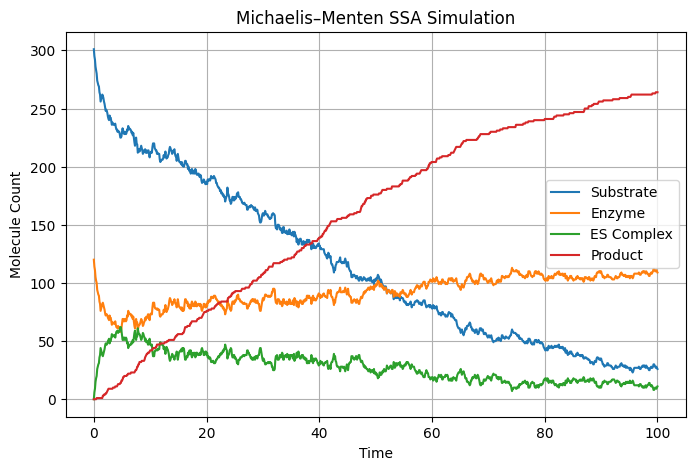

In [10]:
import matplotlib.pyplot as plt
#Temp graph for accuracy checks
sim = gillespy2.Simulation(model, "SSA")
#sim = gillespy2.Simulation(model, NumPySSASolver())
num_traj = 1
for traj in range(num_traj):
    sim.reset() # reset the simulation after each run
    dt = .1;
    times = []
    substrate = []
    enzyme = []
    complex_ = []
    product = []
    prev_t = -1
    end_t = 100;
    while sim.get_time() < end_t:
        t = sim.get_time()
        if t == prev_t:
            raise RuntimeError("Time is not advancing")
        prev_t = t
        times.append(sim.get_time())
        substrate.append(sim.get_species('Substrate'))
        enzyme.append(sim.get_species('Enzyme'))
        complex_.append(sim.get_species('Enzyme_Substrate_Complex'))
        product.append(sim.get_species('Product'))
        #make f string
        #print('traj',traj,' t:',sim.get_time(),' Substrate:',sim.get_species('Substrate'))
        sim.run_until(sim.get_time()+dt);
plt.figure(figsize=(8, 5))
plt.plot(times, substrate, label='Substrate')
plt.plot(times, enzyme, label='Enzyme')
plt.plot(times, complex_, label='ES Complex')
plt.plot(times, product, label='Product')


plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title('Michaelis–Menten SSA Simulation')
plt.legend()
plt.grid(True)
plt.show()

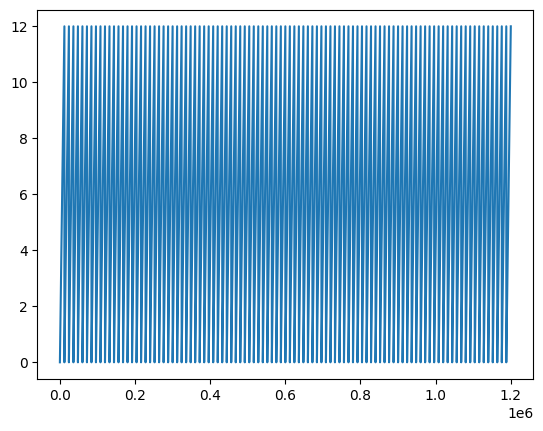

In [14]:
plt.plot(times)

In [13]:
substrate[-1]

np.float64(207.0)